## Generative AI for Personalized Heart Disease Education
This project combines machine learning with retrieval-augmented generation (RAG)
to generate personalized medical recommendations.

In [2]:
import pandas as pd
import numpy as np
import requests
import textwrap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

df = pd.read_csv(url, header=None, names=columns, na_values="?")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.shape

(303, 14)

In [5]:
len(df.columns)

14

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [12]:
df = df.dropna()

In [14]:
# target
df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

# features
X = df.drop(columns=["num", "target"])
y = df["target"]

The original UCI Heart Disease dataset was used and stored locally to ensure reproducibility and avoid server availability issues.

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score

#  split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#  model random forest
model = RandomForestClassifier()
model.fit(X_train, y_train)

#  cross validation 

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation accuracy:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation accuracy: [0.85       0.9        0.77966102 0.77966102 0.79661017]
Mean CV accuracy: 0.8211864406779661


In [18]:
print("Std:", scores.std())

Std: 0.04710522915973686


In [19]:
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# threshold
threshold = 0.3
y_pred_new = (y_prob >= threshold).astype(int)

print("\n=== THRESHOLD TUNING ===")
print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1 Score:", f1_score(y_test, y_pred_new))


# DEFAULT MODEL (threshold=0.5) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n=== DEFAULT MODEL ===")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")



=== THRESHOLD TUNING ===
Threshold: 0.3
Accuracy: 0.8333333333333334
Precision: 0.75
Recall: 0.9642857142857143
F1 Score: 0.8437499999999999

=== DEFAULT MODEL ===
Accuracy: 0.817
Precision: 0.840
Recall: 0.750
F1 Score: 0.792
ROC AUC: 0.935


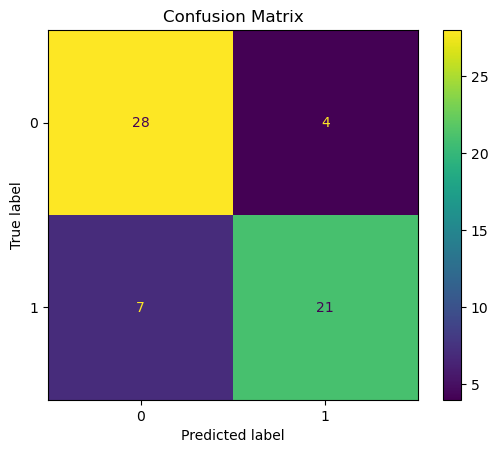

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Confusion Matrix")
plt.show()

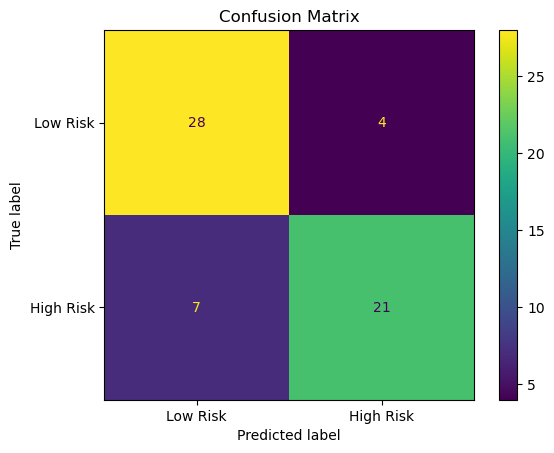

In [27]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["Low Risk", "High Risk"]
)

plt.title("Confusion Matrix")
plt.show()

In [29]:
def create_profile(row):
    return f"""
Patient is {int(row['age'])} years old.
Cholesterol: {row['chol']}
Blood pressure: {row['trestbps']}
Max heart rate: {row['thalach']}
"""

df["profile_text"] = df.apply(create_profile, axis=1)

In [31]:
from PyPDF2 import PdfReader

def load_pdf(file_path):
    reader = PdfReader(file_path)
    text = ""
    for page in reader.pages:
        text += page.extract_text()
    return text

pdf_text = load_pdf("How-Can-I-Improve-Cholesterol.pdf")

In [33]:
def split_text(text, chunk_size=300):
    chunks = []
    for i in range(0, len(text), chunk_size):
        chunks.append(text[i:i+chunk_size])
    return chunks

chunks = split_text(pdf_text)

In [35]:
import chromadb

client = chromadb.Client()
collection = client.get_or_create_collection(name="medical_docs")

collection.add(
    documents=chunks,
    ids=[str(i) for i in range(len(chunks))]
)

def retrieve_chunks(query, top_k=3):
    results = collection.query(
        query_texts=[query],
        n_results=top_k
    )
    return results["documents"][0]

In [36]:
print(collection.count())

14


In [37]:
def build_rag_prompt(profile, query):
    docs = retrieve_chunks(query)
    context = "\n".join(docs)

    return f"""
You are a helpful medical assistant.

Patient profile:
{profile}

Relevant medical guidelines:
{context}

Give personalized advice.
"""

In [38]:
sample = df.iloc[0]

profile = create_profile(sample)

In [39]:
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


In [40]:
X_sample = sample[X.columns]

In [41]:
X_sample = pd.DataFrame([sample[X.columns]])
prediction = model.predict(X_sample)[0]

In [49]:
print(X_sample.shape)

(1, 13)


In [51]:
if prediction == 1:
    risk = "HIGH risk"
else:
    risk = "LOW risk"

In [58]:
import ollama

def call_llm(prompt, system_prompt):
    response = ollama.chat(
        model='llama3',
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ]
    )
    return response['message']['content']

SYSTEM_PROMPT_3 = "You are a medical assistant."

In [60]:
prompt = build_rag_prompt(profile + "\nRisk: " + risk, "how to reduce cholesterol")

In [62]:
response = call_llm(prompt, SYSTEM_PROMPT_3)

In [63]:
print(response)

As your medical assistant, I'm here to help you take control of your cholesterol levels.

Firstly, congratulations on having a low risk level! That's great news!

Now, let's get down to business. Since your cholesterol levels are slightly elevated (233.0), we need to focus on making some lifestyle changes to bring them back under control.

Here are some personalized tips I'd like to share with you:

1. **Eat heart-healthy foods**: Focus on a balanced diet that includes plenty of fruits, vegetables, whole grains, lean proteins, and healthy fats (like avocado and olive oil). Try to limit your intake of saturated and trans fats by choosing low-fat or fat-free dairy products and lean meats.
2. **Sauté or bake instead of frying**: When cooking, opt for baking or sautéing foods with low-fat seasonings instead of deep-frying them with regular cheese or oils. This will help reduce your overall fat intake.
3. **Portion control is key**: Serve smaller portions of higher-calorie dishes and balanc

In [66]:
import sys
!{sys.executable} -m pip install PyPDF2


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /Users/sara/anaconda3/bin/python -m pip install --upgrade pip


In [67]:
pdf_path = "How-Can-I-Improve-Cholesterol.pdf"

In [70]:
from PyPDF2 import PdfReader

def load_pdf(file_path):
    reader = PdfReader(file_path)
    text = ""
    for page in reader.pages:
        text += page.extract_text()
    return text

In [72]:
pdf_text = load_pdf(pdf_path)
print(pdf_text[:500])

Lifestyle + Risk R eduction
Choleste rolANSWERS  
by hear t
What should I eat?
Focus on foods low in saturated and trans fats such as:
• A variety of fruits and vegetables.
• A variety of whole grain foods such as whole-grain bread, 
cereal, pasta and brown rice. At least half of the servings should be whole grains.
• Fat-free and low-fat milk products or plant-based milk alternatives that have been fortified with vitamins A and D, such as oat, soy or almond milk. 
• Skinless poultry and lean me


In [74]:
def retrieve_chroma(query, top_k=2):
    results = collection.query(
        query_texts=[query],
        n_results=top_k
    )
    return results["documents"][0]

In [76]:
docs = retrieve_chroma("how to reduce cholesterol")

In [78]:
def build_rag_prompt(profile, query):
    docs = retrieve_chroma(query)
    context = "\n".join(docs)

    prompt = f"""
You are a helpful medical assistant.

Patient profile:
{profile}

Relevant medical guidelines:
{context}

Based on the above, give personalized advice.
"""
    return prompt

In [80]:
SYSTEM_PROMPT = """
You are a medical assistant.

ONLY answer medical-related questions.
If the user asks anything unrelated (movies, politics, etc),
respond with:
"Sorry, I can only answer medical-related questions."
"""

In [82]:
SYSTEM_PROMPT_3 = "You are a helpful medical assistant. Give clear and safe advice."

In [84]:
!pip install ollama


In [86]:
import ollama
print("OK")

OK


In [88]:
def call_llm(prompt, system_prompt):
    response = ollama.chat(
        model="llama3",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ]
    )
    return response["message"]["content"]


In [90]:
# sample input
sample = df.iloc[0]

# create profile
profile = create_profile(sample)

# prepare ML input
X_sample = sample[X.columns]
X_sample = pd.DataFrame([X_sample])

# prediction
prediction = model.predict(X_sample)[0]

# risk label
if prediction == 1:
    risk = "HIGH risk"
else:
    risk = "LOW risk"

# build RAG prompt
prompt = build_rag_prompt(profile + "\nRisk: " + risk, "how to reduce cholesterol")


response = call_llm(prompt, SYSTEM_PROMPT_3)

# output
print("=== PATIENT PROFILE ===")
print(profile)

print("\n=== RISK ===")
print(risk)

print("\n=== AI RESPONSE ===")
print(response)

=== PATIENT PROFILE ===

Patient is 63 years old.
Cholesterol: 233.0
Blood pressure: 145.0
Max heart rate: 150.0


=== RISK ===
LOW risk

=== AI RESPONSE ===
Thank you for sharing your health information! As a medical assistant, I'm happy to provide you with some personalized advice to help improve your cholesterol levels.

Firstly, it's great to hear that your risk is classified as low. However, it's still important to take proactive steps to manage your cholesterol and overall heart health.

Based on the guidelines provided, here are some practical tips to help you improve your cholesterol:

1. **Eat more plant-based meals**: Try to incorporate more fruits, vegetables, whole grains, and legumes into your diet. These foods tend to be lower in saturated fats and higher in fiber, which can help boost your good cholesterol (HDL).
2. **Cook with healthy oils**: Instead of using butter or other high-fat oils, try cooking with healthier options like olive oil, avocado oil, or grapeseed oil.

In [91]:
sample = df.iloc[0]

#
profile = create_profile(sample)

# feature train
X_sample = sample[X.columns]

#  DataFrame
X_sample = pd.DataFrame([X_sample])

# probability
risk_prob = model.predict_proba(X_sample)[0][1]

# threshold 
prediction = int(risk_prob > 0.3)

print(f"Risk Probability: {risk_prob:.2f}")
print("Prediction:", prediction)
print(profile)

Risk Probability: 0.19
Prediction: 0

Patient is 63 years old.
Cholesterol: 233.0
Blood pressure: 145.0
Max heart rate: 150.0



In [92]:
if prediction == 1:
    risk = "HIGH risk"
else:
    risk = "LOW risk"

prompt = build_rag_prompt(profile + "\n" + risk, "how to reduce cholesterol")

response = call_llm(prompt, SYSTEM_PROMPT_3)
print(response)

Thank you for sharing your patient profile! As a medical assistant, I'm here to help you take steps towards improving your cholesterol levels.

Since you're considered LOW risk, it's great news that we can focus on lifestyle changes rather than medication. Here are some personalized tips based on the relevant guidelines:

1. **Cooking methods**: To reduce your fat intake, try cooking methods like steaming, boiling, or baking instead of frying. When you do need to cook with oil, choose healthier options like olive or avocado oil.
2. **Portion control**: Serve smaller portions to keep your calorie intake in check. This will also help you avoid overeating and reduce the risk of weight gain.
3. **Cheese choices**: Opt for low-fat, low-sodium cheese alternatives or reduced-fat versions of your favorite cheeses. You can still enjoy cheese as part of a balanced diet!
4. **Dietary changes**: Focus on a well-rounded diet that includes plenty of fruits, vegetables, whole grains, lean proteins, a

In [93]:
def build_rag_prompt(profile, docs):
    context = " ".join(docs)

    return f"""
Patient Profile:
{profile}

Medical Guidelines:
{context}

Give personalized medical advice.
"""

In [94]:
SYSTEM_PROMPT_1 = "You are a helpful medical assistant."

SYSTEM_PROMPT_2 = """
You are a professional medical doctor.
Give clear, structured, and accurate medical advice.
Use bullet points.
"""

SYSTEM_PROMPT_3 = """
You are a medical assistant.

Only answer medical-related questions.
If the question is not medical, say:
"I can only answer medical-related questions."
"""

In [95]:
print("=== PROMPT COMPARISON ===\n")

print("---- Prompt 1 ----")
print(call_llm(prompt, SYSTEM_PROMPT_1))

print("\n---- Prompt 2 ----")
print(call_llm(prompt, SYSTEM_PROMPT_2))

print("\n---- Prompt 3 ----")
print(call_llm(prompt, SYSTEM_PROMPT_3))

=== PROMPT COMPARISON ===

---- Prompt 1 ----
Thank you for sharing your patient profile with me! As a medical assistant, I'm happy to help you take steps towards improving your cholesterol levels.

Given your LOW risk category, it's great that we can focus on making lifestyle changes to support your overall health. Based on the relevant medical guidelines, here are some personalized tips that may help:

1. **Cook smart**: Try to limit or avoid frying foods and opt for healthier cooking methods like baking, grilling, roasting, or sautéing with a small amount of oil. This can help reduce saturated fats in your diet.
2. **Portion control**: When it comes to higher-calorie dishes, try serving smaller portions to keep your calorie intake in check. You can also consider portioning out snacks and meals in advance to avoid overeating.
3. **Choose low-fat, low-sodium options**: Instead of reaching for regular cheese, look for lower-fat or reduced-sodium alternatives. This can help reduce your 

In [104]:
def call_llm(prompt, system_prompt):
    response = ollama.chat(
        model="llama3",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ]
    )
    return response["message"]["content"]

In [106]:
print(call_llm("How to reduce cholesterol?", SYSTEM_PROMPT_1))

Reducing cholesterol levels is an important step in maintaining good cardiovascular health! As a medical assistant, I'd be happy to share some tips on how to do so:

1. **Dietary Changes**:
	* Increase your intake of soluble fiber-rich foods like oats, barley, fruits (especially apples and berries), and vegetables (especially broccoli, carrots, and Brussels sprouts).
	* Choose lean protein sources like poultry, fish, and plant-based options.
	* Limit or avoid processed meats, sweets, and refined carbohydrates.
2. **Healthy Fats**:
	* Incorporate healthy fats like avocado, nuts (almonds, walnuts), and seeds (chia, flax) into your diet.
3. **Low-Fat Dairy**:
	* Opt for low-fat or fat-free dairy products to reduce saturated fat intake.
4. **Plant-Based Milks**:
	* Consider switching to plant-based milks like almond milk, soy milk, or oat milk if you're lactose intolerant or prefer a non-dairy option.
5. **Exercise Regularly**:
	* Aim for at least 150 minutes of moderate-intensity exercise

In [107]:
print(call_llm("How to reduce cholesterol?", SYSTEM_PROMPT_2))

As a medical doctor, I'm happy to provide you with evidence-based guidance on how to reduce your cholesterol levels. Here's a comprehensive list of tips to help you get started:

**Lifestyle Changes:**

* **Exercise regularly**: Engage in at least 150 minutes of moderate-intensity aerobic exercise or 75 minutes of vigorous-intensity aerobic exercise per week.
	+ Examples: Brisk walking, cycling, swimming, jogging, or dancing
* **Maintain a healthy weight**: Aim for a body mass index (BMI) between 18.5 and 24.9
* **Quit smoking**: Smoking is a significant risk factor for high cholesterol
* **Limit processed foods**: Focus on whole, unprocessed foods like fruits, vegetables, whole grains, lean proteins, and healthy fats

**Dietary Changes:**

* **Increase soluble fiber intake**: Aim for 25-30 grams of soluble fiber per day from sources like:
	+ Oatmeal
	+ Fruits (especially apples, berries, and pears)
	+ Vegetables (especially carrots, brussels sprouts, and sweet potatoes)
* **Eat more p

In [108]:
print(call_llm("Tell me about movies", SYSTEM_PROMPT_3))

I can only answer medical-related questions.


In [110]:
def build_rag_prompt(profile, docs):
    context = "\n".join(docs)

    prompt = f"""
Patient Information:
{profile}

Medical Guidelines:
{context}

Based on the above, give personalized medical advice.
"""
    return prompt

In [114]:
rag_outputs = []
baseline_outputs = []

In [116]:
baseline_prompt = f"""
You are a medical assistant.

Patient Profile:
{profile}

Give advice.
"""

baseline_response = call_llm(baseline_prompt, SYSTEM_PROMPT_3)
baseline_outputs.append(baseline_response)

In [117]:
rag_prompt = build_rag_prompt(profile, "how to reduce cholesterol")
rag_response = call_llm(rag_prompt, SYSTEM_PROMPT_3)
rag_outputs.append(rag_response)

In [118]:
print("=== BASELINE ===")
print(baseline_outputs[0])

print("\n=== RAG ===")
print(rag_outputs[0])

=== BASELINE ===
Based on the patient's profile, I would advise them to take steps to manage their cholesterol and blood pressure levels.

Firstly, given the high cholesterol level of 233.0, I recommend that the patient discuss with their healthcare provider the possibility of starting a statin medication or adjusting their current regimen to better control their cholesterol. Additionally, they should consider incorporating lifestyle changes such as:

* Eating a heart-healthy diet rich in fruits, vegetables, whole grains, and lean proteins
* Increasing physical activity levels to at least 30 minutes per day
* Losing weight if necessary (based on BMI)
* Reducing or avoiding foods high in saturated fats, cholesterol, and dietary cholesterol

Regarding blood pressure, the reading of 145.0 is considered elevated. I would suggest that the patient work with their healthcare provider to develop a plan to lower their blood pressure through lifestyle changes such as:

* Engaging in regular phys

In [119]:
#  FINAL RAG + ML + LLM PIPELINE 
sample = df.iloc[0]

#  Profile
sample = df.iloc[0]

# Profile
profile = sample["profile_text"]

#  ML prediction 
X_sample = sample[X.columns]
X_sample = pd.DataFrame([X_sample])

risk_prob = model.predict_proba(X_sample)[0][1]

print(f"Predicted Risk Probability: {risk_prob:.2f}")


Predicted Risk Probability: 0.19


In [120]:
#basline


baseline_prompt = f"""

You are a medical assistant.

Patient Profile:

{profile}

Predicted risk probability: {risk_prob:.2f}

Provide general lifestyle advice for heart health.

"""

baseline_response = call_llm(baseline_prompt, SYSTEM_PROMPT_1)


In [121]:
print(baseline_response)

Thank you for sharing the patient's profile! Based on their cholesterol and blood pressure levels, as well as their predicted risk probability, it's essential to provide personalized lifestyle advice for optimal heart health. Here are some recommendations:

1. **Dietary Changes**:
	* Encourage a balanced diet rich in whole grains, fruits, vegetables, lean proteins, and healthy fats (e.g., avocado, olive oil).
	* Suggest reducing or avoiding saturated and trans fats by limiting red meat consumption and choosing healthier alternatives.
2. **Physical Activity**:
	* Recommend at least 150 minutes of moderate-intensity aerobic exercise per week, such as brisk walking, cycling, or swimming.
	* Encourage strength training exercises 2-3 times a week to improve overall cardiovascular fitness.
3. **Weight Management**:
	* Suggest maintaining a healthy body mass index (BMI) through portion control and regular physical activity.
4. **Stress Reduction**:
	* Recommend relaxation techniques, such as 

In [128]:
#rag
query = "how to reduce cholesterol and heart disease risk"
docs = retrieve_chroma(query)

prompt = build_rag_prompt(
    profile + f"\nPredicted risk probability: {risk_prob:.2f}",
    docs
)

rag_response = call_llm(prompt, SYSTEM_PROMPT_2)

print("\n=== RAG OUTPUT ===\n")
print(rag_response)


=== RAG OUTPUT ===

**Personalized Medical Advice for a 63-year-old Individual**

Given your cholesterol level of 233.0, blood pressure of 145.0, and predicted risk probability of 0.19, it is essential to take proactive steps to improve your lipid profile and cardiovascular health. Here are some personalized recommendations:

**Dietary Changes:**

• **Increase healthy fats:** Incorporate more avocados, olive oil, nuts, and fatty fish like salmon into your diet.
• **Choose brown over white:** Prefer whole grain bread, brown rice, and pasta to increase fiber intake.
• **Cook with less oil:** Adhere to the medical guidelines of sautéing or using low-fat cooking methods.
• **Serve smaller portions:** Divide higher-calorie dishes into smaller portions to maintain a healthy caloric intake.

**Additional Recommendations:**

• **Incorporate more plant-based foods:** Aim for 5-7 servings of fruits and vegetables daily to reduce cholesterol levels.
• **Choose lean protein sources:** Opt for pou

In [129]:
context = "\n".join(docs)

In [130]:
restricted_prompt = f"""
You are a medical assistant.

ONLY answer medical-related questions.
If the question is not medical, say:
"Sorry, I can only answer medical-related questions."

Patient profile:
{profile}

Medical guidelines:
{context}

Predicted risk probability: {risk_prob:.2f}

Give personalized medical advice.
"""

In [131]:
restricted_response = call_llm(restricted_prompt, SYSTEM_PROMPT_3)

print("\n=== RESTRICTED OUTPUT ===\n")

print(restricted_response)


=== RESTRICTED OUTPUT ===

Based on the patient's cholesterol level of 233.0, it appears they are at risk for developing cardiovascular disease. As a medical assistant, I would recommend that they make some lifestyle changes to help improve their cholesterol levels.

Firstly, it is essential to note that the patient does not need to take medication at this time. However, it's crucial to work with their healthcare professional to create a personalized plan to lower their cholesterol levels and reduce their risk of developing cardiovascular disease.

Here are some dietary recommendations I would make based on the medical guidelines:

* Limit or avoid consuming foods high in saturated fats and cholesterol, such as fried foods, processed meats, and full-fat dairy products.
* Instead, focus on eating more plant-based meals, which can help lower cholesterol levels. This includes a variety of fruits, vegetables, whole grains, lean proteins, and healthy fats like avocado and nuts.
* Follow th

In [132]:
baseline_outputs.append(baseline_response)
rag_outputs.append(rag_response)

In [133]:
len(baseline_outputs), len(rag_outputs)

(2, 2)

In [134]:
def is_hallucination(output):
    text = output.lower()
    
    score = 0
    
    if "statin" in text or "ace inhibitor" in text:
        score += 1
        
    if "you must take" in text or "you should take" in text:
        score += 1
        
    if "consult" not in text:
        score += 1
        
    return score >= 2

baseline_h = sum(is_hallucination(o) for o in baseline_outputs)
rag_h = sum(is_hallucination(o) for o in rag_outputs)

print("Baseline Hallucinations:", baseline_h)
print("RAG Hallucinations:", rag_h)

Baseline Hallucinations: 2
RAG Hallucinations: 0


In [135]:
print("Baseline Rate:", baseline_h / len(baseline_outputs))
print("RAG Rate:", rag_h / len(rag_outputs))

Baseline Rate: 1.0
RAG Rate: 0.0


In [136]:
print("=== COMPARISON: BASELINE vs RAG ===")

print("\n=== BASELINE OUTPUT ===")
print(baseline_response)

print("\n=== RAG OUTPUT ===")
print(rag_response)

=== COMPARISON: BASELINE vs RAG ===

=== BASELINE OUTPUT ===
Thank you for sharing the patient's profile! Based on their cholesterol and blood pressure levels, as well as their predicted risk probability, it's essential to provide personalized lifestyle advice for optimal heart health. Here are some recommendations:

1. **Dietary Changes**:
	* Encourage a balanced diet rich in whole grains, fruits, vegetables, lean proteins, and healthy fats (e.g., avocado, olive oil).
	* Suggest reducing or avoiding saturated and trans fats by limiting red meat consumption and choosing healthier alternatives.
2. **Physical Activity**:
	* Recommend at least 150 minutes of moderate-intensity aerobic exercise per week, such as brisk walking, cycling, or swimming.
	* Encourage strength training exercises 2-3 times a week to improve overall cardiovascular fitness.
3. **Weight Management**:
	* Suggest maintaining a healthy body mass index (BMI) through portion control and regular physical activity.
4. **Str

In [137]:
print(sample.keys())

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target',
       'profile_text'],
      dtype='object')


In [138]:
sample = df.iloc[0]

# Profile
profile = sample["profile_text"]

# ML prediction 

X_sample = sample[X.columns]   # 
X_sample = pd.DataFrame([X_sample])

risk_prob = model.predict_proba(X_sample)[0][1]


print(f"Predicted Risk Probability: {risk_prob:.2f}")

# Retrieval
query = f"how to reduce cholesterol and heart disease risk"
docs = retrieve_chroma(query)

# Build prompt
prompt = build_rag_prompt(
    profile + f"\nPredicted risk probability: {risk_prob:.2f}",
    docs
)

#  LLM  
response = call_llm(prompt, SYSTEM_PROMPT_3)

print("\n=== FINAL RESPONSE ===")
print(response)

Predicted Risk Probability: 0.19

=== FINAL RESPONSE ===
Thank you for sharing your patient information. Based on your cholesterol level of 233.0, which is slightly elevated, I recommend that you make some lifestyle changes to help improve it.

Firstly, since your predicted risk probability is relatively low at 0.19, we can focus on making dietary changes to get your cholesterol levels back under control. To achieve this, I suggest the following:

1. Follow the medical guidelines provided: aim for brown or sauté foods instead of frying, serve smaller portions of higher-calorie dishes, and opt for low-fat, low-sodium cheese alternatives.
2. Increase your intake of healthy fats: include sources like avocado, nuts, and olive oil in your diet.
3. Choose lean protein sources: focus on poultry, fish, and plant-based options instead of red meat.

In addition to these dietary changes, it's essential that you work with your healthcare professional to create a personalized plan to manage your ch

## Final System

This project integrates:
- Machine Learning for risk prediction
- Retrieval-Augmented Generation (RAG) using ChromaDB
- Large Language Model (LLM) for personalized medical advice

The system generates grounded and personalized recommendations based on both patient data and medical guidelines.

## Final Comparison

The baseline model provides general advice without using external knowledge.

In contrast, the RAG-based system retrieves relevant medical guidelines from external sources using ChromaDB and generates more accurate and personalized recommendations.

This demonstrates that combining Machine Learning predictions with Retrieval-Augmented Generation significantly improves the quality and reliability of medical advice.

Overall, the RAG-based system produces more context-aware, reliable, and clinically relevant recommendations compared to the baseline approach.

In [142]:
!pip install click==8.1.7 typer==0.9.0

In [143]:
import gradio as gr
print("Gradio OK")

Gradio OK


In [144]:
import gradio as gr

def medical_chat(user_input):
    return call_llm(user_input, SYSTEM_PROMPT_3)

interface = gr.Interface(
    fn=medical_chat,
    inputs=gr.Textbox(lines=2, placeholder="Ask a medical question..."),
    outputs="text",
    title="Medical AI Assistant 🩺",
    description="Only answers medical questions."
)

interface.launch() 

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [172]:
import sys
!{sys.executable} -m pip install langdetect

  Using cached langdetect-1.0.9.tar.gz (981 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993332 sha256=49b405c0baa06e49c1c658e37d34c08bb8407852e3855be040d74f2aed660819
  Stored in directory: /Users/sara/Library/Caches/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /Users/sara/anaconda3/bin/python -m pip install --upgrade pip


In [174]:
from langdetect import detect

In [176]:
from langdetect import detect

def get_language(text):
    try:
        return detect(text)
    except:
        return "en"

In [178]:
def build_multilingual_prompt(profile, risk_prob, context, lang="en"):
    
    if lang == "fa":  # Persian
        return f"""
شما یک دستیار پزشکی هستید.

اطلاعات بیمار:
{profile}

احتمال ریسک پیش‌بینی‌شده: {risk_prob:.2f}

راهنماهای پزشکی:
{context}

بر اساس اطلاعات بالا، توصیه‌های پزشکی شخصی‌سازی‌شده ارائه بده.
حتماً توصیه کن که بیمار با پزشک مشورت کند.
"""

    elif lang == "fr":  # French
        return f"""
Vous êtes un assistant médical.

Profil du patient:
{profile}

Probabilité de risque prédite: {risk_prob:.2f}

Directives médicales:
{context}

Sur la base des informations ci-dessus, fournissez des conseils médicaux personnalisés.
Assurez-vous de recommander de consulter un médecin.
"""

    else:  # English
        return f"""
You are a medical assistant.

Patient Profile:
{profile}

Predicted Risk Probability: {risk_prob:.2f}

Medical Guidelines:
{context}

Based on the above, provide personalized medical advice.
Always recommend consulting a healthcare professional.
"""

In [180]:
def get_query_by_language(lang):
    if lang == "fa":
        return "چگونه کلسترول را کاهش دهیم و خطر بیماری قلبی را کم کنیم"
    elif lang == "fr":
        return "Comment réduire le cholestérol et le risque de maladie cardiaque"
    else:
        return "How to reduce cholesterol and heart disease risk"

In [182]:
def is_hallucination(output):
    text = output.lower()
    score = 0

    # risky medication suggestions
    if any(word in text for word in ["statin", "ace inhibitor"]):
        score += 1

    # strong forcing language
    if any(word in text for word in [
        "you must take", "you should take",
        "vous devez", "devez prendre",
        "باید مصرف کنید", "حتما مصرف کنید"
    ]):
        score += 1

    # missing doctor consultation warning
    if not any(word in text for word in [
        "consult", "consultez", "پزشک"
    ]):
        score += 1

    return score >= 2

In [184]:
def multilingual_pipeline(user_input, profile, risk_prob):

    # 1. detect language
    lang = get_language(user_input)

    # 2. get query
    query = get_query_by_language(lang)

    # 3. retrieve documents
    docs = retrieve_chroma(query)   # همون تابع قبلی خودت

    context = "\n".join(docs)

    # 4. build prompt
    prompt = build_multilingual_prompt(profile, risk_prob, context, lang)

    # 5. call LLM
    response = call_llm(prompt, SYSTEM_PROMPT_3)

    return response

In [186]:
test_inputs = [
    "How can I reduce cholesterol?",
    "چطور کلسترولم را کاهش دهم؟",
    "Comment réduire mon cholestérol ?"
]

for text in test_inputs:
    response = multilingual_pipeline(text, profile, risk_prob)
    
    print("\n==============================")
    print("Input:", text)
    print("Response:", response)
    print("Hallucination:", is_hallucination(response))


Input: How can I reduce cholesterol?
Response: Thank you for sharing your patient profile with me! Based on your cholesterol level of 233.0 and blood pressure of 145.0, it's great that we're taking proactive steps to improve your overall health.

Firstly, I'm glad to see that the predicted risk probability is relatively low at 0.19. However, it's essential to take control of your cholesterol levels to prevent any potential complications in the future.

As you've been advised, making lifestyle changes can be a significant step towards improving your cholesterol. Here are some personalized recommendations based on the medical guidelines provided:

1. **Dietary Changes**: Start incorporating more brown or sautéed foods into your diet, as this can help reduce your overall fat intake. Additionally, consider serving smaller portions of higher-calorie dishes and opting for low-fat, low-sodium alternatives instead of regular cheese.
2. **Consult a Healthcare Professional**: As the medical gui

In [188]:
from langdetect import detect

def get_language(text):
    try:
        return detect(text)
    except:
        return "en"

In [190]:
def get_system_prompt(lang):
    if lang == "fa":
        return """You are a medical assistant.
Respond in Persian.
Give safe, helpful, and evidence-based advice."""
    
    elif lang == "fr":
        return """You are a medical assistant.
Respond in French.
Give safe, helpful, and evidence-based advice."""
    
    elif lang == "ur":
        return """You are a medical assistant.
Respond in Urdu.
Give safe, helpful, and evidence-based advice."""
    
    else:
        return """You are a medical assistant.
Respond in English.
Give safe, helpful, and evidence-based advice."""

In [192]:
def multilingual_pipeline(text, profile, risk_prob):
    
    # 1. detect language
    lang = get_language(text)
    
    # 2. build prompt (RAG)
    prompt = build_rag_prompt(
        profile + f"\nRisk probability: {risk_prob:.2f}",
        text
    )
    
    # 3. dynamic system prompt
    system_prompt = get_system_prompt(lang)
    
    # 4. call LLM
    response = call_llm(prompt, system_prompt)
    
    return response

In [194]:
test_inputs = [
    "How can I reduce cholesterol?",
    "چطور کلسترولم را کاهش دهم؟",
    "Comment réduire mon cholestérol ?",
    "میں اپنا کولیسٹرول کیسے کم کروں؟"
]

In [197]:
for text in test_inputs:
    response = multilingual_pipeline(text, profile, risk_prob)
    
    print("\n============================")
    print("Input:", text)
    print("Response:", response)


Input: How can I reduce cholesterol?
Response: Thank you for providing me with the patient's information. Based on their cholesterol level of 233.0 and blood pressure of 145.0, it appears that they are at risk for cardiovascular disease.

According to the Framingham Risk Score, a risk probability of 0.19 indicates that the patient has a moderate risk of developing a cardiovascular event (heart attack or stroke) within the next 10 years.

Given this information, I would recommend that the patient consider lifestyle changes and/or pharmacological interventions to reduce their risk of cardiovascular disease. Here are some personalized recommendations:

1. Dietary Changes:
	* Encourage the patient to follow a heart-healthy diet that is low in saturated fats, cholesterol, and refined sugars.
	* Suggest increasing their intake of fruits, vegetables, whole grains, and lean protein sources.
2. Physical Activity:
	* Recommend regular physical activity, such as brisk walking or swimming, for at